# Tracé de mesure des 4 inducteurs
## Import

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Nom du fichier généré par le script d'acquisition
MesTot = 'Machine_etat_bloque.csv'

# Chargement des données avec Pandas
df = pd.read_csv(MesTot)

# Chargement du temps
t = df['Temps(s)'].to_numpy()

# Regroupement des données par inducteur
donnees = {}
for i in range(1, 5):
    donnees[i] = {
        'pos_c': df[f'Pos_C{i}(mm)'].to_numpy(),
        'pos_m': df[f'Pos_M{i}(mm)'].to_numpy(),
        'err': df[f'Err_Pos_{i}(mm)'].to_numpy(),
        'cur_c': df[f'Cur_C{i}(A)'].to_numpy(),
        'cur_m': df[f'Cur_M{i}(A)'].to_numpy(),
        'force_c': df[f'Force_C{i}'].to_numpy(),
        'xr': df[f'Xr_{i}'].to_numpy(),
        'vit': df[f'Vit_{i}'].to_numpy(),
    }

## Tracé

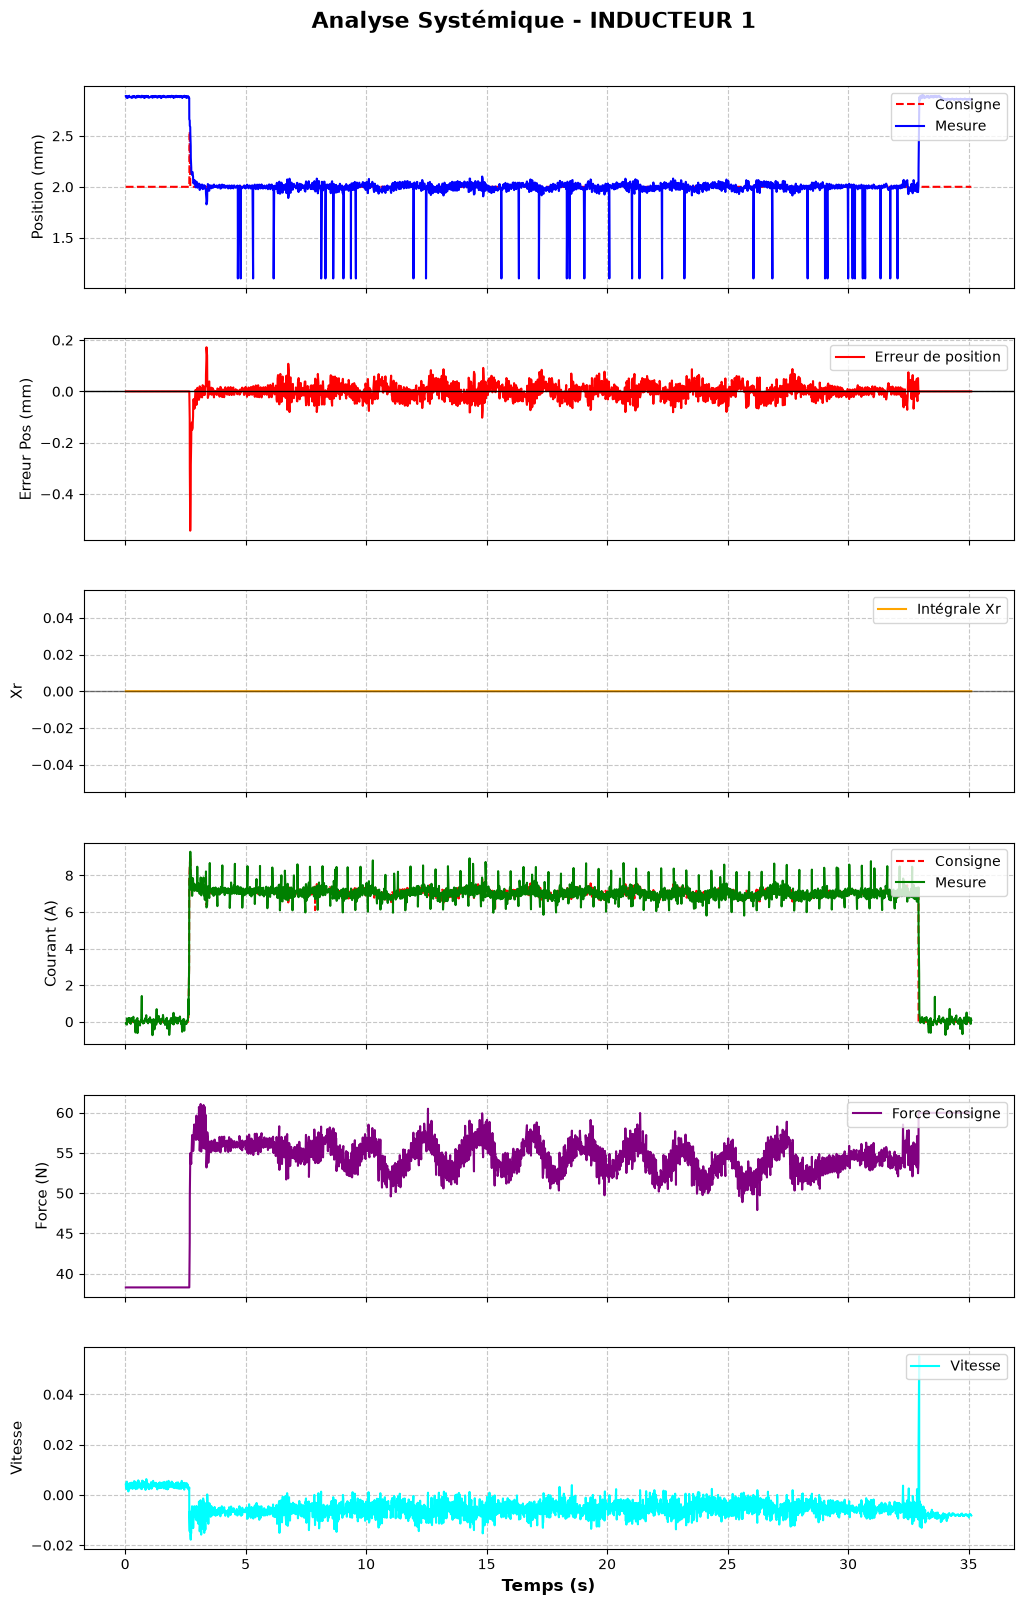

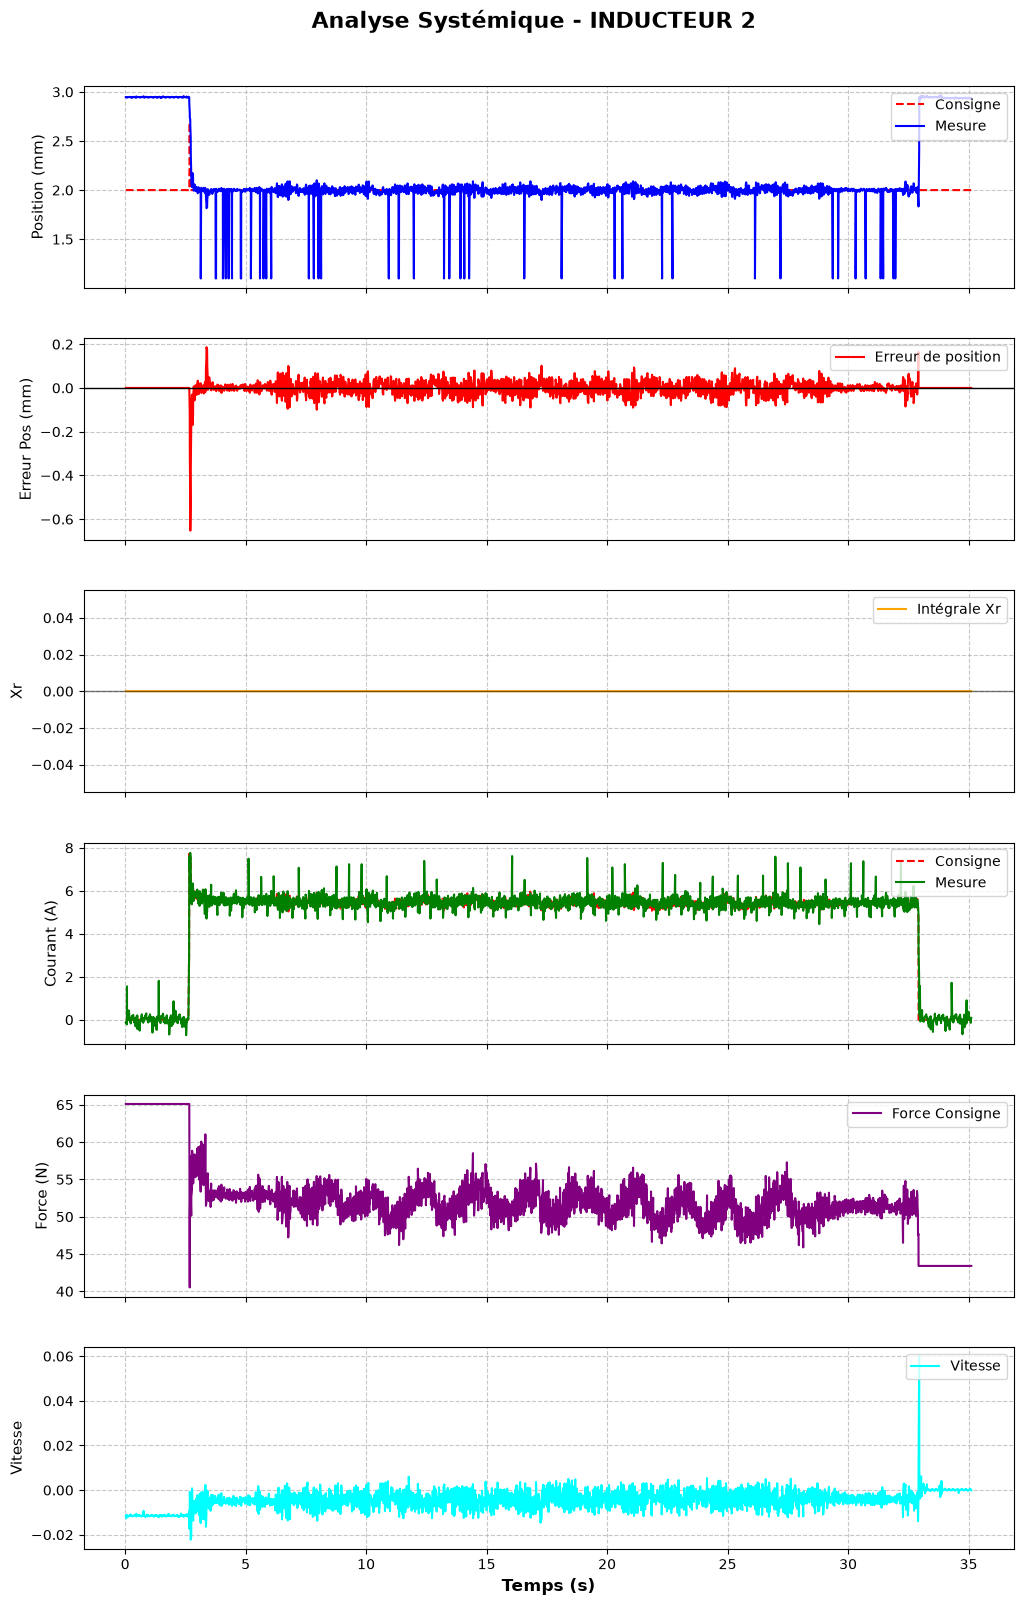

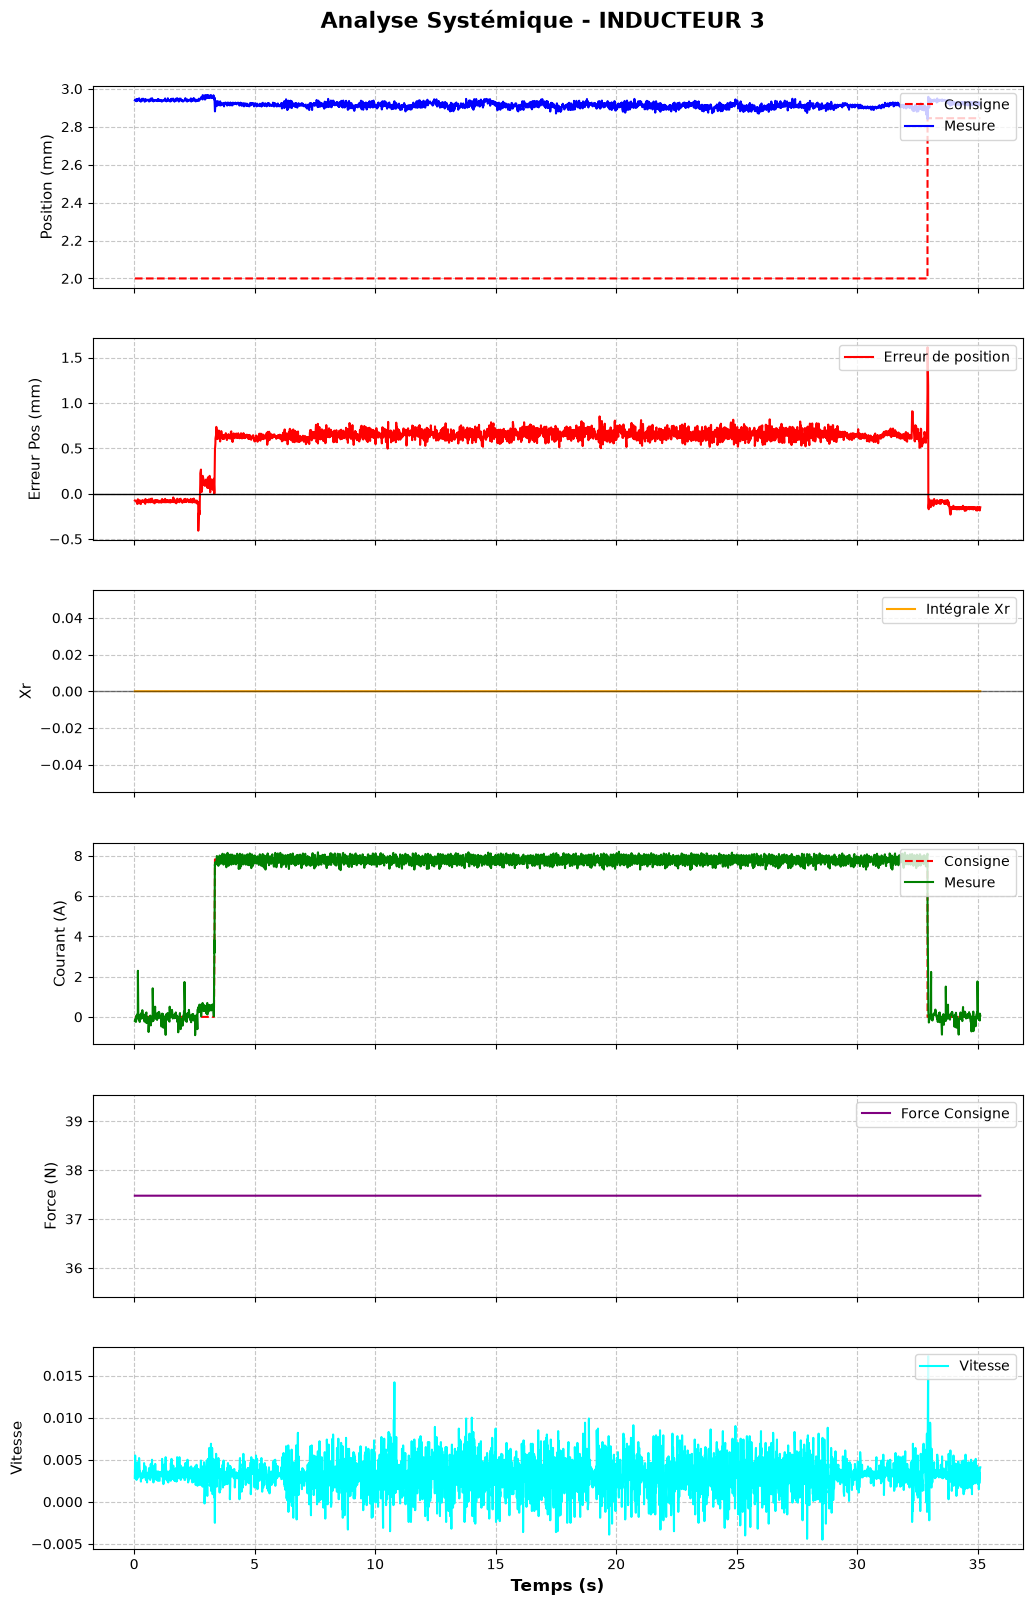

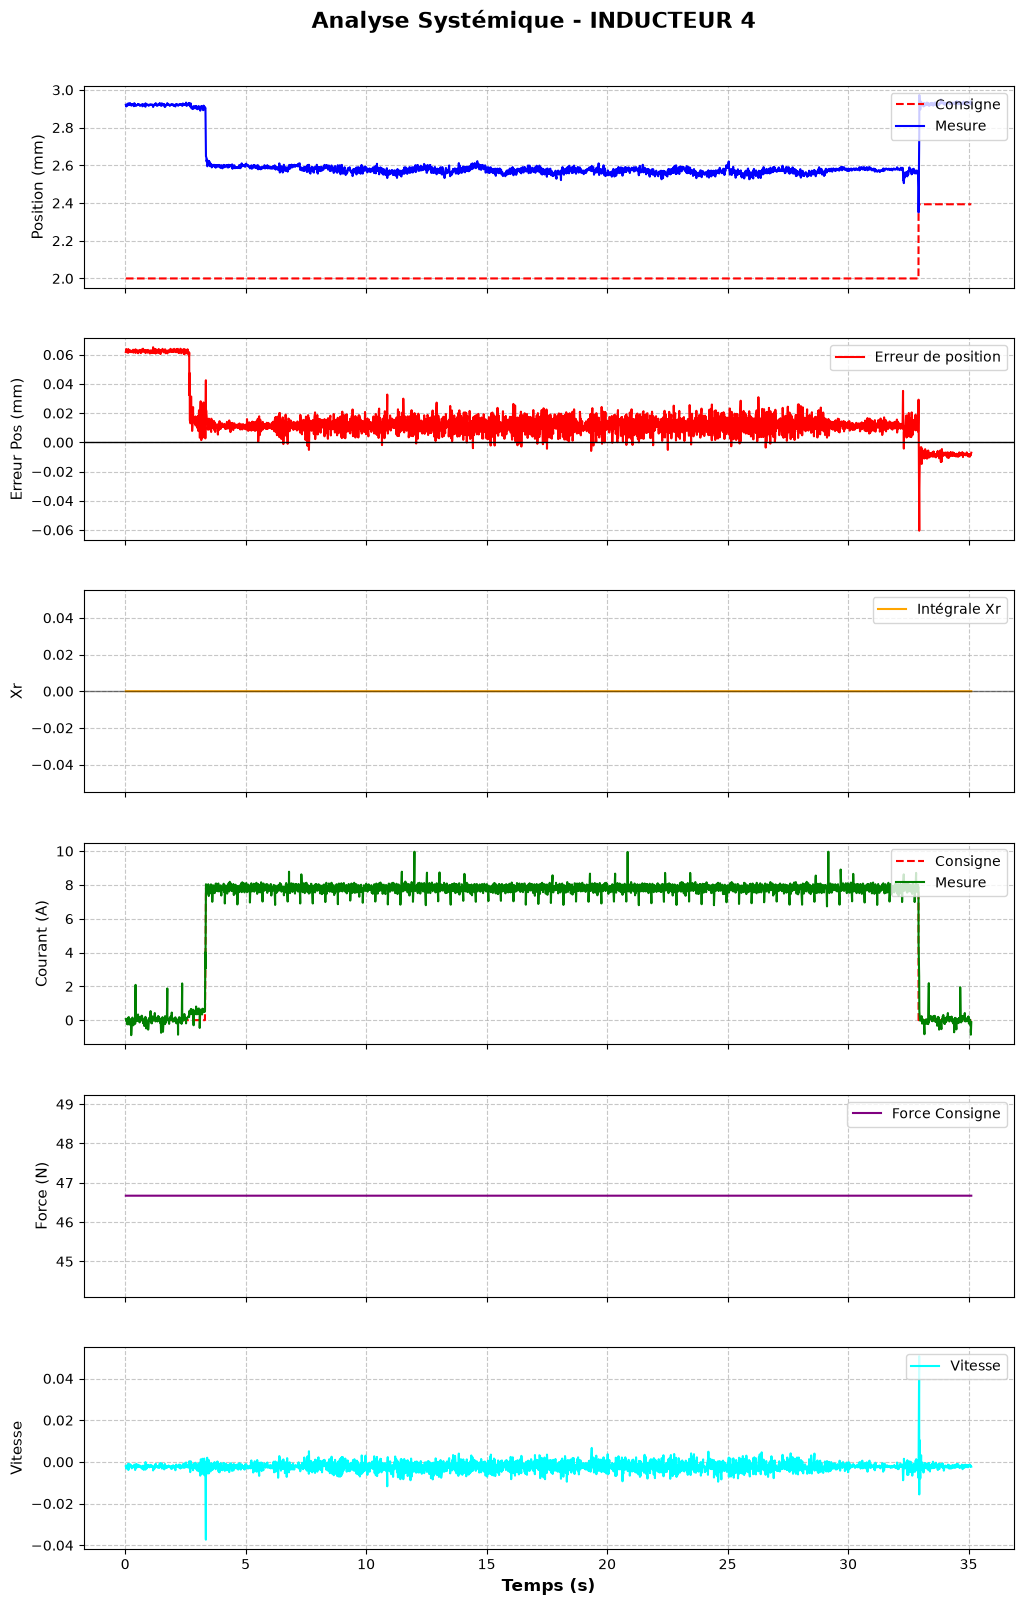

In [14]:
# Tracé séparé pour chaque inducteur
for i in range(1, 5):
    data = donnees[i]
    fig, axs = plt.subplots(6, 1, figsize=(12, 19), sharex=True)

    axs[0].plot(t, data['pos_c'], label='Consigne', color='red', linestyle='--', linewidth=1.5)
    axs[0].plot(t, data['pos_m'], label='Mesure', color='blue', linewidth=1.5)
    axs[0].set_ylabel("Position (mm)", fontsize=11)
    axs[0].legend(loc="upper right")
    axs[0].grid(True, linestyle='--', alpha=0.7)

    axs[1].plot(t, data['err'], label='Erreur de position', color='red', linewidth=1.5)
    axs[1].axhline(0, color='black', linewidth=1)
    axs[1].set_ylabel("Erreur Pos (mm)", fontsize=11)
    axs[1].legend(loc="upper right")
    axs[1].grid(True, linestyle='--', alpha=0.7)

    axs[2].plot(t, data['xr'], label='Intégrale Xr', color='orange', linewidth=1.5)
    axs[2].axhline(0, color='black', linewidth=1, alpha=0.5)
    axs[2].set_ylabel("Xr", fontsize=11)
    axs[2].legend(loc="upper right")
    axs[2].grid(True, linestyle='--', alpha=0.7)

    axs[3].plot(t, data['cur_c'], label='Consigne', color='red', linestyle='--', linewidth=1.5)
    axs[3].plot(t, data['cur_m'], label='Mesure', color='green', linewidth=1.5)
    axs[3].set_ylabel("Courant (A)", fontsize=11)
    axs[3].legend(loc="upper right")
    axs[3].grid(True, linestyle='--', alpha=0.7)

    axs[4].plot(t, data['force_c'], label='Force Consigne', color='purple', linewidth=1.5)
    axs[4].set_ylabel("Force (N)", fontsize=11)
    axs[4].legend(loc="upper right")
    axs[4].grid(True, linestyle='--', alpha=0.7)

    axs[5].plot(t, data['vit'], label='Vitesse', color='cyan', linewidth=1.5)
    axs[5].set_ylabel("Vitesse", fontsize=11)
    axs[5].set_xlabel("Temps (s)", fontsize=12, fontweight='bold')
    axs[5].legend(loc="upper right")
    axs[5].grid(True, linestyle='--', alpha=0.7)

    plt.suptitle(f"Analyse Systémique - INDUCTEUR {i}", fontsize=16, fontweight='bold', y=0.92)
    plt.subplots_adjust(hspace=0.25)
    plt.show()